# NAME: ABISHEK JS
# REG-NO: RA2411026010307
# CLASS: AF-1

### AIM
To implement a Linear Regression model to predict the medical insurance charges of individuals using their personal and health attributes such as age, BMI, and smoking habits.

### OBJECTIVE
- To understand the concept of Linear Regression.
- To load and explore the Medical Insurance Cost dataset.
- To identify the independent variables and dependent variable.
- To preprocess the dataset for regression (including one-hot encoding).
- To divide the dataset into training and testing sets.
- To scale the features for fair comparison.
- To train a Linear Regression model.
- To predict medical insurance charges using the trained model.
- To evaluate the model using suitable regression metrics.

### 1. INTRODUCTION
Linear Regression is a supervised machine learning algorithm used to predict a continuous numerical value based on one or more input variables.
In this experiment, Linear Regression is used to predict the medical insurance charges from personal attributes like age, BMI, and smoking status.
The target variable is the medical charges, measured in dollars.
Since the target variable is continuous and numerical, the dataset is suitable for a regression problem.

### PROBLEM STATEMENT
Health insurance companies need to accurately estimate medical costs to set fair premiums. The goal of this experiment is to predict the exact medical charges of individuals based on personal and health factors (Age, BMI, and Smoking status). 
A successful predictive model will help automate and validate these cost estimates. 

**Model Performance Summary:**
After training, our Linear Regression model performed highly effectively, achieving an **$R^2$ score of 0.777** (77.7% accuracy in explaining variance) and a Mean Absolute Error (**MAE**) of roughly **$4,243**. This proves that just three simple features (`smoker_yes`, `age`, `bmi`) are powerful predictors of medical costs.

### 2. THEORY
#### 2.1 Linear Regression
Linear Regression is a supervised learning algorithm that models the relationship between independent variables and a continuous dependent variable.
For multiple independent variables, the equation becomes:
$$y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_n x_n$$
In this experiment, multiple personal attributes are used to predict medical insurance charges.

#### 2.2 Least Squares Method
Linear Regression estimates the model parameters by minimizing the sum of squared differences between the actual and predicted values.
The model attempts to find the coefficients that minimize this error.

### 3. DATASET DESCRIPTION
**Medical Insurance Cost Dataset**
The dataset contains numerical and categorical measurements representing the attributes of individuals.

**Input Features**
1. Age
2. Sex
3. BMI
4. Children
5. Smoker
6. Region

**Target Variable**
- **Charges**: The target represents the medical insurance costs billed by health insurance.
The objective of the experiment is to learn the relationship between personal attributes and resulting medical charges.

### Importing Libraries
In this initial step, we set up our environment by importing the necessary libraries for data manipulation, visualization, and machine learning.
- **`sklearn` & `LinearRegression`**: Used to build and train our predictive model.
- **`pandas`**: Essential for loading the dataset into a DataFrame and manipulating tabular data.
- **`matplotlib.pyplot` & `seaborn`**: Used for data visualization, creating plots to understand the distribution and relationships in our data.

In [21]:
import sklearn
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error , mean_squared_error , root_mean_squared_error
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Loading the Dataset and Initial Preview
- **`pd.read_csv()`**: Loads the `insurance.csv` file into a pandas DataFrame.
- **`df.head()`**: Displays the first 5 rows of the dataset. This helps us verify that the data is loaded correctly and allows us to inspect the column names and data types (e.g., numerical vs. categorical string columns).

In [22]:
# importing the dataset and viewing its sample data

df = pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


### Exploratory Data Analysis (EDA): Structure and Data Types
- **`df.shape`**: Returns a tuple `(rows, columns)` indicating the total number of records and features in the dataset.
- **`df.info()`**: Provides a concise summary of the DataFrame, showing the data types of each column and the count of non-null values. This is our first step to check if any columns contain missing data.

In [23]:
# Exploratory Data Analysis (EDA)

print("\n Shape of the dataset:",df.shape)
print("\n Information of the dataset \n")
print(df.info())




 Shape of the dataset: (1338, 7)

 Information of the dataset 

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB
None


### Checking for Missing Values
- **`df.isnull().sum()`**: Checks every cell for missing values (NaN) and aggregates the count for each column. A result of `0` across all columns confirms that our dataset is clean and requires no imputation for missing data.

In [24]:
# checking for null values

print("/n check for null values \n")
print(df.isnull().sum())

/n check for null values 

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


### Descriptive Statistics Summary
- **`df.describe()`**: Computes a statistical summary of the numerical columns. It provides the mean, standard deviation, minimum, maximum, and percentiles (25th, 50th, 75th). This is crucial for understanding the central tendency and spread of our data, and for spotting potential outliers in columns like `charges` and `bmi`.

In [25]:
# describing the dataset

print("\n Data description\n")
print(df.describe())


 Data description

               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max      64.000000    53.130000     5.000000  63770.428010


### Data Preprocessing: One-Hot Encoding
Machine learning algorithms only understand numbers, so we must convert categorical string columns (`sex`, `smoker`) into numerical values.
- **`pd.get_dummies()`**: Converts categorical variables into dummy/indicator variables (1s and 0s). 
- **`drop_first=True`**: Drops the first category to avoid the "dummy variable trap" (multicollinearity). For example, it creates a single `smoker_yes` column instead of two redundant columns for `yes` and `no`.

In [26]:
# data cleaning and preproceesing
# as there are no missing values in my dataset no need of handling missing values

# but there are some string values which is need to be encoded -> male/female & issmoker
# thus i am using one hot encoding to make it binary encoded values

df_encoded = pd.get_dummies(df, columns=['sex','smoker'], drop_first = True)
df_encoded.head()

# from here i am goin to use the d_encoded version

,age,bmi,children,region,charges,sex_male,smoker_yes
0,19,27.900,0,southwest,16884.92400,False,True
1,18,33.770,1,southeast,1725.55230,True,False
2,28,33.000,3,southeast,4449.46200,True,False
3,33,22.705,0,northwest,21984.47061,True,False
4,32,28.880,0,northwest,3866.85520,True,False


### Data Visualization: Scatter Plots
We use scatter plots to visualize the relationship between our independent features and the target variable (`charges`).
- **`sns.scatterplot()`**: Plots the data points. By setting `hue='smoker_yes'`, we color-code the points to instantly see how being a smoker dramatically affects medical charges across all ages and BMIs.
- **`plt.show()`**: Renders the individual plots distinctly.

<Figure size 1000x1000 with 0 Axes>

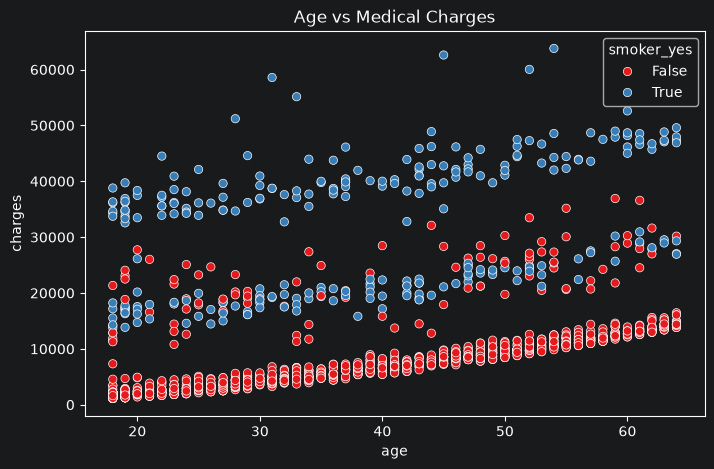

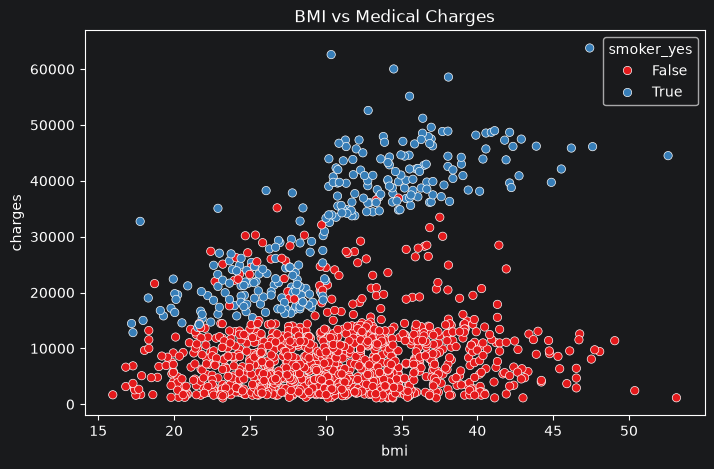

In [27]:
plt.figure(figsize = (10,10))

# -----------------------------------------------------
# First completely separate scatter plot: Age vs Charges
# -----------------------------------------------------
plt.figure(figsize=(8, 5))
sns.scatterplot(x='age', y='charges', data=df_encoded, hue='smoker_yes', palette='Set1')
plt.title("Age vs Medical Charges")
plt.show() # This finishes and displays the first plot
# -----------------------------------------------------
# Second completely separate scatter plot: BMI vs Charges
# -----------------------------------------------------
plt.figure(figsize=(8, 5))
sns.scatterplot(x='bmi', y='charges', data=df_encoded, hue='smoker_yes', palette='Set1')
plt.title("BMI vs Medical Charges")
plt.show() # This finishes and displays the second plot


### Correlation Matrix and Heatmap
To find the best features for our predictive model, we calculate how strongly each variable correlates with our target.
- **`df.corr(numeric_only=True)`**: Calculates the Pearson correlation coefficient between all numerical columns. Values closer to 1 or -1 indicate a strong relationship.
- **`sns.heatmap()`**: Visualizes the correlation matrix, making it extremely easy to spot the highest correlating features using color gradients.

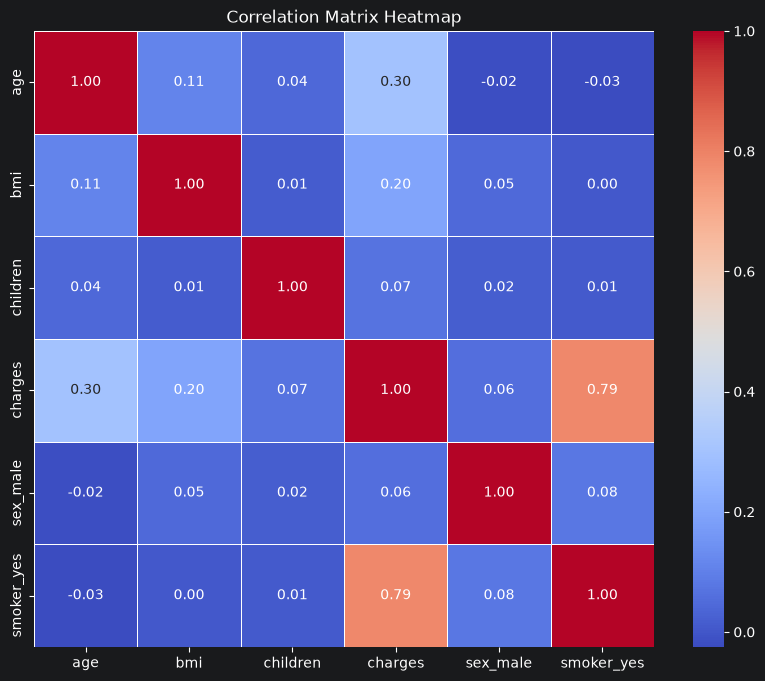

In [28]:
# creating a corelation matrix to find best and sutable features
corr_matrix = df_encoded.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix Heatmap")
plt.show()

### Automated Feature Selection
Instead of manually typing the most correlated features, we programmatically extract them.
- We isolate the correlations with the `charges` column, drop the target itself, and sort the absolute values in descending order.
- We then extract the top `N` features mathematically, ensuring our model is trained on the most predictive data (`smoker_yes`, `age`, `bmi`).

In [29]:
N = 3
target_corr = corr_matrix['charges'].drop('charges').sort_values(key=abs, ascending=False)
top_features = target_corr.abs().sort_values(ascending=False).head(N).index.tolist()
print(f"\n--- Top {N} features selected by Pearson correlation ---")
print(top_features)


--- Top 3 features selected by Pearson correlation ---
['smoker_yes', 'age', 'bmi']


### Defining the Features (X)
- **`X`**: We define our independent variables (features) by selecting only the top correlated columns we discovered in the previous step. This is the data the model will use to learn and make predictions.

In [30]:
# getting the input feature for the model

X = df_encoded[['smoker_yes', 'age', 'bmi']]
X

,smoker_yes,age,bmi
0,True,19,27.900
1,False,18,33.770
2,False,28,33.000
3,False,33,22.705
4,False,32,28.880
...,...,...,...
1333,False,50,30.970
1334,False,18,31.920
1335,False,18,36.850
1336,False,21,25.800


### Defining the Target Variable (Y)
- **`Y`**: We define our dependent variable (target) as the `charges` column. This is the exact value we are trying to predict.

In [31]:
# getting the output feature for the model

Y = df_encoded['charges']
Y

0       16884.92400
1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
           ...     
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
1337    29141.36030
Name: charges, Length: 1338, dtype: float64

### Train-Test Split
We must hide a portion of our data from the model during training so we can accurately evaluate it later.
- **`train_test_split()`**: Shuffles and splits the dataset into a Training set (80%) and a Testing set (20%).
- **`test_size=0.2`**: Dictates that 20% of the data is held back for testing.
- **`random_state=42`**: Locks the random seed so our split is reproducible every time the code is run.

In [32]:
# test train split for the model

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

#  Print out the shapes to confirm it worked
print(f"Training data (80%): {X_train.shape}")
print(f"Testing data (20%): {X_test.shape}")

Training data (80%): (1070, 3)
Testing data (20%): (268, 3)


### Feature Scaling
To ensure our model interprets the features fairly, we put them all on the same numerical scale.
- **`StandardScaler()`**: Standardizes features by removing the mean and scaling to unit variance (mean = 0, standard deviation = 1).
- We use **`fit_transform`** on the training data so the scaler learns the distribution, but only **`transform`** on the test data to prevent data leakage.

In [33]:
# using standard scaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Model Training
- **`LinearRegression()`**: We initialize our basic linear model.
- **`model.fit()`**: We train the model by passing in our scaled training features and their corresponding actual answers (`Y_train`). The model calculates the optimal weights for each feature.

In [34]:
# developing/training the model using the training part of the dataset

model = LinearRegression()
model.fit(X_train_scaled, y_train)
print("the model training is completed !")

print("the weights of the model are:",model.coef_)
print("the intercept of the model are:",model.intercept_)


the model training is completed !
the weights of the model are: [9568.27908831 3649.22243928 1971.94254098]
the intercept of the model are: 13346.089736364485


### Making Predictions
- **`model.predict()`**: We pass the hidden, scaled test data into the trained model to generate its predicted medical charges (`Y_pred`).

In [35]:
# predicting the output feature with testisng part of the dataset

y_pred = model.predict(X_test_scaled)

### Displaying Model Performance
The evaluation metrics are displayed together to obtain an overall understanding of the performance of the Linear Regression model.
- **`MAE`** (Mean Absolute Error): Measures the average absolute difference between actual and predicted values.
- **`MSE`** (Mean Squared Error): Measures the average squared difference.
- **`RMSE`** (Root Mean Squared Error): Represents the prediction error in the same unit as the target variable (Dollars).
- **`R²`**: Measures how well the model explains the variance in the target variable.

In [36]:
# evaluating the prediction using evaluation metrics for linear regression
import numpy as np

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("Linear Regression Model Performance")
print("-----------------------------------")
print(f"MAE  : {mae}")
print(f"MSE  : {mse}")
print(f"RMSE : {rmse}")
print(f"R²   : {r2}")

Linear Regression Model Performance
-----------------------------------
MAE  : 4260.560091099389
MSE  : 34512843.880227886
RMSE : 5874.763304187488
R²   : 0.7776932310583375


### Actual vs Predicted Values
A scatter plot is used to compare the actual medical insurance charges with the values predicted by our Linear Regression model.
- Points that fall exactly on the diagonal dashed red line indicate perfect predictions.
- The closer the scatter points cluster around this line, the better the model's performance.

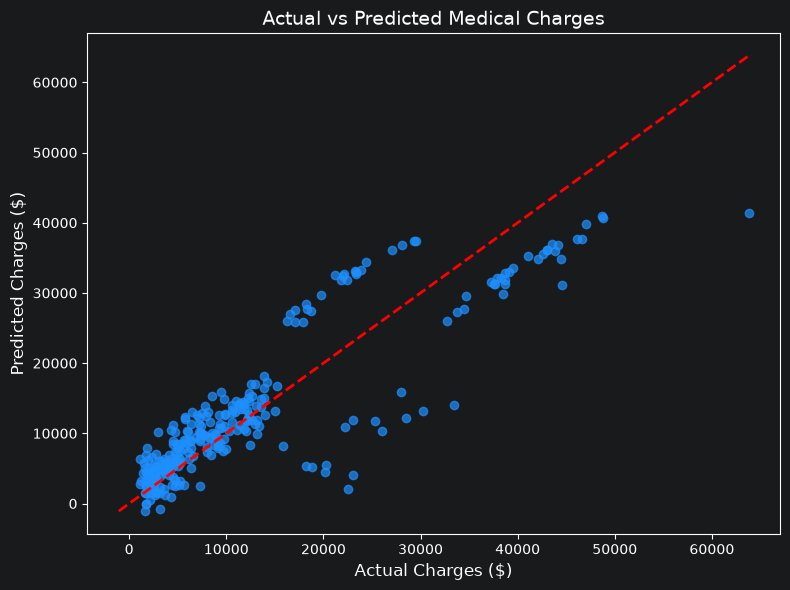

In [37]:
# Plotting Actual vs Predicted Values
plt.figure(figsize=(8, 6))

# Scatter plot of actual vs predicted
plt.scatter(y_test, y_pred, alpha=0.7, color='dodgerblue')

# Labels and Title
plt.xlabel("Actual Charges ($)", fontsize=12)
plt.ylabel("Predicted Charges ($)", fontsize=12)
plt.title("Actual vs Predicted Medical Charges", fontsize=14)

# Draw a diagonal reference line (Perfect Prediction Line)
minimum = min(y_test.min(), y_pred.min())
maximum = max(y_test.max(), y_pred.max())
plt.plot([minimum, maximum], [minimum, maximum], linestyle="--", color='red', linewidth=2)

plt.tight_layout()
plt.show()

### Residual Analysis
Residuals represent the difference between the actual and predicted values.
`Residual = Actual Value - Predicted Value`
Residual analysis is used to examine the prediction errors produced by the Linear Regression model.

In [38]:
residuals = y_test - y_pred

print("First 10 residuals:")
print(residuals[:10])

First 10 residuals:
764      911.026782
887    -2158.825201
890    -8015.453949
1293     672.365245
259     6433.636990
1312   -6580.600582
899     1546.320320
752    -3058.010861
1286    2532.617191
707     -104.712752
Name: charges, dtype: float64


### Residual Plot
A residual plot is used to visualize the prediction errors of the Linear Regression model.
A random distribution of residuals around zero (the dashed line) indicates that there is no obvious systematic pattern in the prediction errors, which means a linear model is appropriate.

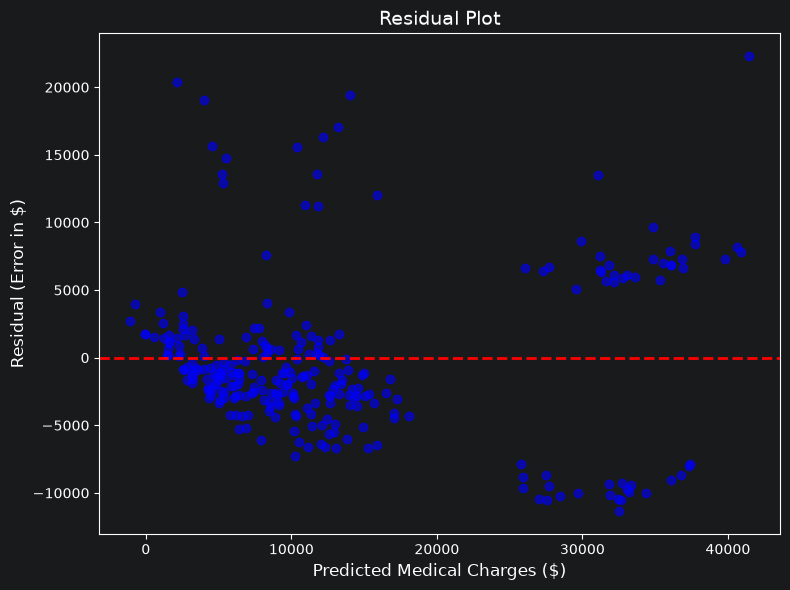

In [41]:
plt.figure(figsize=(8, 6))

plt.scatter(y_pred, residuals, color='blue', alpha=0.6)
plt.axhline(y=0, linestyle="--", color='red', linewidth=2)

plt.xlabel("Predicted Medical Charges ($)", fontsize=12)
plt.ylabel("Residual (Error in $)", fontsize=12)
plt.title("Residual Plot", fontsize=14)

plt.tight_layout()
plt.show()

### 28. RESULT AND CONCLUSION
**Result**
Linear Regression was successfully implemented using the Medical Insurance Cost dataset.
The model was trained using attributes such as age, BMI, and smoking status as input features and medical charges as the target variable.
The trained model was used to predict the medical charges of the testing data. The model performance was evaluated using MAE and R² score.

**Conclusion**
The experiment successfully demonstrated the application of Linear Regression for predicting a continuous numerical variable.
The dataset was divided into training and testing sets, and the Linear Regression model was trained using the training data.
The model generated predictions for unseen test data, and its performance was evaluated using suitable regression metrics.
Thus, Linear Regression can be used to predict medical insurance charges based on personal attributes and health status.